In [3]:
import keras
from keras import backend as K
from keras.layers import Layer
from keras.initializers import RandomUniform, Initializer, Constant
import numpy as np

In [4]:
class InitCentersRandom(Initializer):
    """ Initializer for initialization of centers of RBF network
        as random samples from the given data set.
    # Arguments
        X: matrix, dataset to choose the centers from (random rows
          are taken as centers)
    """

    def __init__(self, X):
        self.X = X

    def __call__(self, shape, dtype=None):
        assert shape[1] == self.X.shape[1]
        idx = np.random.randint(self.X.shape[0], size=shape[0])
        return self.X[idx, :]

In [5]:
class RBFLayer(Layer):
    """ Layer of Gaussian RBF units.
    # Example
    ```python
        model = Sequential()
        model.add(RBFLayer(10,
                           initializer=InitCentersRandom(X),
                           betas=1.0,
                           input_shape=(1,)))
        model.add(Dense(1))
    ```
    # Arguments
        output_dim: number of hidden units (i.e. number of outputs of the
                    layer)
        initializer: instance of initiliazer to initialize centers
        betas: float, initial value for betas
    """

    def __init__(self, output_dim, initializer=None, betas=1.0, **kwargs):
        self.output_dim = output_dim
        self.init_betas = betas
        if not initializer:
            self.initializer = RandomUniform(0.0, 1.0)
        else:
            self.initializer = initializer
        super(RBFLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.centers = self.add_weight(name='centers',
                                       shape=(self.output_dim, input_shape[1]),
                                       initializer=self.initializer,
                                       trainable=True)
        self.betas = self.add_weight(name='betas',
                                     shape=(self.output_dim,),
                                     initializer=Constant(
                                         value=self.init_betas),
                                     # initializer='ones',
                                     trainable=True)

        super(RBFLayer, self).build(input_shape)

    def call(self, x):

        C = K.expand_dims(self.centers)
        H = K.transpose(C-K.transpose(x))
        return K.exp(-self.betas * K.sum(H**2, axis=1))

        # C = self.centers[np.newaxis, :, :]
        # X = x[:, np.newaxis, :]

        # diffnorm = K.sum((C-X)**2, axis=-1)
        # ret = K.exp( - self.betas * diffnorm)
        # return ret

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.output_dim)

    def get_config(self):
        # have to define get_config to be able to use model_from_json
        config = {
            'output_dim': self.output_dim
        }
        base_config = super(RBFLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

In [6]:
from keras.initializers import Initializer
from sklearn.cluster import KMeans

In [7]:
class InitCentersKMeans(Initializer):
    """ Initializer for initialization of centers of RBF network
        by clustering the given data set.
    # Arguments
        X: matrix, dataset
    """

    def __init__(self, X, max_iter=100):
        self.X = X
        self.max_iter = max_iter

    def __call__(self, shape, dtype=None):
        assert shape[1] == self.X.shape[1]

        n_centers = shape[0]
        km = KMeans(n_clusters=n_centers, max_iter=self.max_iter, verbose=0)
        km.fit(self.X)
        return km.cluster_centers_

In [9]:
import numpy as np, pandas as pd
from keras.models import Sequential 
from keras.layers import Dense
from keras.layers import Activation
from keras.optimizers import RMSprop
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv('housing_price_dataset.csv',header=None)
data.head(10) #Return 10 rows of data

,0,1,2,3,4,5
0,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
1,2126,4,1,Rural,1969,215355.28361820139
2,2459,3,2,Rural,1980,195014.22162584803
3,1860,2,1,Suburb,1970,306891.0120763329
4,2294,2,1,Urban,1996,206786.78715332696
5,2130,5,2,Suburb,2001,272436.239065061
6,2095,2,3,Suburb,2020,198208.80390657106
7,2724,2,1,Suburb,1993,343429.3191099182
8,2044,4,3,Rural,1957,184992.321268412
9,2638,4,3,Urban,1959,377998.58815204125


SquareFeet      1
Bedrooms        1
Bathrooms       1
Neighborhood    1
YearBuilt       1
Price           1
Name: 0, dtype: int64


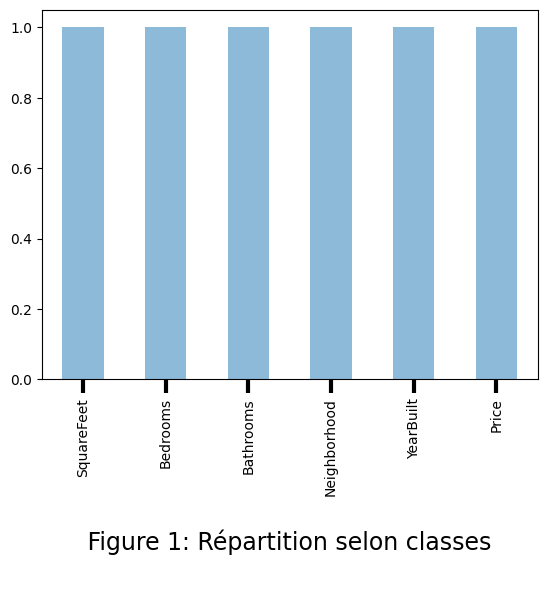

In [13]:
datatrans=np.transpose(data)
print(datatrans[0].value_counts())
datatrans[0].value_counts()[:].plot(kind='bar', alpha=0.5)
plt.xlabel('\n Figure 1: Répartition selon classes \n', fontsize='17', horizontalalignment='center')
plt.tick_params(axis='x',  direction='out', length=10, width=3)
plt.show() #2300

In [ ]:
X=data.iloc[2:570,:].values
y = data.iloc[0:1,:].values

In [ ]:
X=np.transpose(X)
y=np.transpose(y)
print('rotation ')
print(X)
print(y)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
X = MinMaxScaler().fit_transform(X)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
y = ohe.fit_transform(y).toarray()
print('resulats de scalling')
print(X,y)

In [ ]:
from sklearn.model_selection import train_test_split
from keras.optimizers import SGD
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=0)#80% train et 20% test

In [ ]:
model = Sequential()
rbflayer = RBFLayer(34,
                        initializer=InitCentersKMeans(X_train),
                        betas=3.0,
                        input_shape=(568,))
model.add(rbflayer)
model.add(Dense(4))
model.add(Activation('linear'))
model.compile(loss='mean_squared_error',
                  optimizer=RMSprop(), metrics=['accuracy'])
print(model.summary())
history1 = model.fit(X_train, y_train, epochs=1000, batch_size=32)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['loss'])
plt.title('train accuracy and loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'loss'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.models import  load_model
newmodel1= load_model("Zoghbio.h5",
                          custom_objects={'RBFLayer': RBFLayer})
print("OK")

In [ ]:
print("Evaluate on test data")
results = newmodel1.evaluate(X_test, y_test, batch_size=32)
print("test loss:", results[0])
print("test accuracy:",results[1]*100,'%')